# Interpretación y explicabilidad del modelo
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook interpreta el modelo con mejor desempeño del notebook 05, el **Random Forest** (ROC-AUC 0.9941 sobre el conjunto de prueba). El objetivo es entender qué variables usa para decidir y en qué dirección influyen, no solo cuánto acierta.

**Contenido:**
1. Carga del mejor modelo y del conjunto de prueba
2. Importancia global de las variables (8.1)
3. Interpretación con SHAP y Summary Plot (8.2)
4. Dirección del efecto de cada variable (8.3)
5. Diferencias entre lagos en la explicación
6. Lectura ambiental de los patrones encontrados (8.4)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import joblib
import shap

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

np.random.seed(42)
Path('./data').mkdir(exist_ok=True)
print('shap', shap.__version__)

shap 0.52.0


## 1. Carga del mejor modelo y del conjunto de prueba

Se usa `mejor_modelo.pkl`, guardado en el notebook 05, y el mismo conjunto de prueba del 30 % que sirvió para la evaluación, de modo que la interpretación se hace sobre datos que el modelo no vio durante el entrenamiento. Los índices guardados en `idx_test.parquet` permiten recuperar el lago y la fecha de cada observación de prueba.

In [2]:
modelo = joblib.load('./modelos/mejor_modelo.pkl')

X_test = pd.read_parquet('./data/X_test.parquet').astype('float64')
y_test = pd.read_parquet('./data/y_test.parquet').squeeze()
idx_test = pd.read_parquet('./data/idx_test.parquet')['idx'].values

meta = pd.read_parquet('./data/dataset_ml_con_respuesta.parquet',
                       columns=['lago', 'fecha', 'lon', 'lat'])
meta['lago'] = meta['lago'].str.strip().str.lower()
meta_test = meta.loc[idx_test].reset_index(drop=True)

print(f'Modelo: {type(modelo).__name__} con {modelo.n_estimators} árboles, '
      f'profundidad máxima {modelo.max_depth}')
print(f'Conjunto de prueba: {len(X_test):,} observaciones x {X_test.shape[1]} variables')
print(f'Clase 1 en prueba: {y_test.sum():,} ({100*y_test.mean():.2f}%)')
print('Observaciones por lago en prueba:')
print(meta_test['lago'].value_counts().to_string())

Modelo: RandomForestClassifier con 137 árboles, profundidad máxima 20
Conjunto de prueba: 4,054,414 observaciones x 12 variables
Clase 1 en prueba: 90,327 (2.23%)
Observaciones por lago en prueba:


lago
atitlan      3583999
amatitlan     470415


## 2. Importancia global de las variables (8.1)

Se calculan dos medidas complementarias:

- **Importancia por impureza (Gini)**: la que trae el Random Forest. Es gratuita porque se acumula durante el entrenamiento, pero tiende a favorecer a las variables continuas y con muchos valores distintos, que ofrecen más puntos de corte posibles.
- **Importancia por permutación**: se mide cuánto cae el ROC-AUC al desordenar al azar los valores de una variable en el conjunto de prueba. Es más costosa pero más fiable, porque evalúa el efecto sobre datos no vistos y no depende de la estructura interna del árbol.

La permutación se calcula sobre una submuestra estratificada de 200,000 observaciones de prueba con 5 repeticiones, suficiente para estabilizar el resultado sin recorrer los 4 millones de píxeles.

In [3]:
importancias_gini = pd.Series(
    modelo.feature_importances_, index=X_test.columns
).sort_values(ascending=False)

print('Importancia por impureza (Gini):')
print(importancias_gini.round(4).to_string())

Importancia por impureza (Gini):
NDVI                0.3200
mes_cos             0.1136
lon                 0.1027
lat                 0.0983
brillo_B03_B08      0.0766
B03                 0.0665
B08                 0.0582
lago_atitlan        0.0490
NDWI                0.0470
mes_sin             0.0293
dist_centro_lago    0.0260
epoca_lluviosa      0.0127


In [4]:
X_perm, _, y_perm, _ = train_test_split(
    X_test, y_test, train_size=200_000, stratify=y_test, random_state=42
)
print(f'Submuestra para permutación: {len(X_perm):,} obs '
      f'(clase 1: {y_perm.sum():,}, {100*y_perm.mean():.2f}%)')

t0 = time.time()
perm = permutation_importance(
    modelo, X_perm, y_perm,
    scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=1
)
print(f'Calculado en {time.time()-t0:.1f} s')

importancias_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
desv_perm = pd.Series(perm.importances_std, index=X_test.columns)

print()
print('Importancia por permutación (caída de ROC-AUC al desordenar la variable):')
print(pd.DataFrame({'caída media': importancias_perm,
                    'desv': desv_perm[importancias_perm.index]}).round(4).to_string())

Submuestra para permutación: 200,000 obs (clase 1: 4,456, 2.23%)


Calculado en 130.5 s

Importancia por permutación (caída de ROC-AUC al desordenar la variable):
                  caída media    desv
NDVI                   0.1580  0.0016
mes_cos                0.0467  0.0003
lat                    0.0160  0.0002
lon                    0.0143  0.0002
B03                    0.0086  0.0002
mes_sin                0.0085  0.0003
brillo_B03_B08         0.0072  0.0002
dist_centro_lago       0.0067  0.0001
NDWI                   0.0065  0.0003
B08                    0.0051  0.0002
lago_atitlan           0.0038  0.0001
epoca_lluviosa         0.0032  0.0000


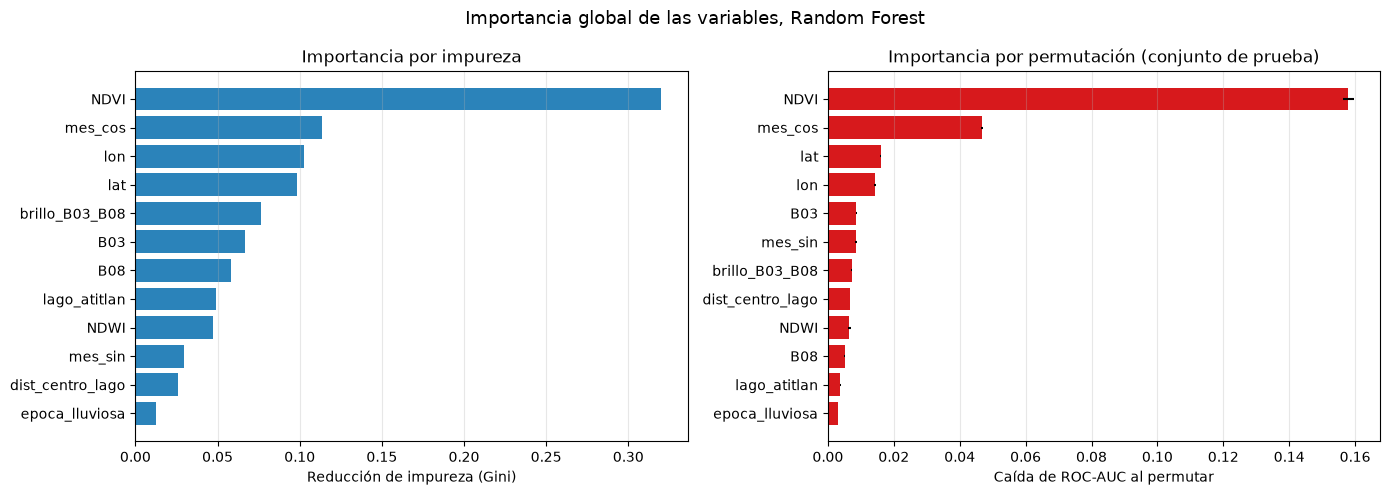

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = importancias_gini.sort_values(ascending=True)
axes[0].barh(orden.index, orden.values, color='#2b83ba')
axes[0].set_xlabel('Reducción de impureza (Gini)')
axes[0].set_title('Importancia por impureza')
axes[0].grid(axis='x', alpha=0.3)

orden_p = importancias_perm.sort_values(ascending=True)
axes[1].barh(orden_p.index, orden_p.values,
             xerr=desv_perm[orden_p.index].values, color='#d7191c')
axes[1].set_xlabel('Caída de ROC-AUC al permutar')
axes[1].set_title('Importancia por permutación (conjunto de prueba)')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Importancia global de las variables, Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

**Lo que muestran las dos medidas.** Coinciden en lo esencial: NDVI es la variable más importante por un margen amplio. Permutarla hace caer el ROC-AUC en 0.1580 puntos, más del triple que la segunda variable (`mes_cos`, 0.0467), y ninguna otra pasa de 0.0160.

También coinciden en el segundo bloque: `mes_cos`, `lat` y `lon`. Es decir, después del NDVI el modelo se apoya en cuándo y dónde se tomó el píxel más que en las bandas espectrales. B03, B08, el brillo y el NDWI producen caídas de ROC-AUC de entre 0.0051 y 0.0086, un orden de magnitud por debajo del NDVI.

Las dos medidas difieren en `dist_centro_lago` (posición 11 por impureza y 8 por permutación) y en `brillo_B03_B08` (5 y 7). La diferencia es esperable: la importancia por impureza premia a las variables con muchos valores distintos, mientras que la permutación mide el efecto real sobre datos no vistos. Cuando discrepan, la permutación es la referencia más confiable.

## 3. Interpretación con SHAP (8.2)

SHAP reparte la predicción de cada observación entre las variables: el valor SHAP de una variable indica cuánto empuja esa observación hacia la clase 1 (valor positivo) o hacia la clase 0 (valor negativo), respecto de la predicción media del modelo. A diferencia de las importancias globales, permite ver también **en qué dirección** actúa cada variable y si esa dirección es la misma en todas las observaciones.

**Muestras utilizadas.** TreeSHAP sobre este bosque cuesta alrededor de 1 segundo por observación, porque son 137 árboles de profundidad 20 con casi 7 millones de nodos en total. Por eso se trabaja con dos muestras pequeñas del conjunto de prueba:

- **Muestra representativa (500 observaciones)**, tomada al azar y por lo tanto con la proporción real de clases (2.23 % de positivos). Se usa para el ranking global de importancia SHAP.
- **Muestra estratificada (500 de clase 0 y 500 de clase 1)**, para el summary plot. Con la proporción real solo habría unos 11 píxeles positivos en 500, insuficientes para ver el comportamiento del modelo en zonas con floración. Sobremuestrear la clase 1 cambia la composición de la nube de puntos del gráfico, pero no altera el valor SHAP de cada observación, que es una atribución local.

In [6]:
rng = np.random.RandomState(42)

# Muestra representativa (distribución real de clases)
idx_rep = rng.choice(len(X_test), 500, replace=False)

# Muestra estratificada (500 por clase)
pos = np.flatnonzero(y_test.values == 1)
neg = np.flatnonzero(y_test.values == 0)
idx_est = np.concatenate([rng.choice(neg, 500, replace=False),
                          rng.choice(pos, 500, replace=False)])
rng.shuffle(idx_est)

X_rep = X_test.iloc[idx_rep]
X_est = X_test.iloc[idx_est]
y_est = y_test.iloc[idx_est]
lago_est = meta_test['lago'].iloc[idx_est]

print(f'Muestra representativa: {len(X_rep)} obs, clase 1: {y_test.iloc[idx_rep].sum()}')
print(f'Muestra estratificada: {len(X_est)} obs, clase 1: {y_est.sum()}')
print('Lagos en la muestra estratificada:')
print(lago_est.value_counts().to_string())

Muestra representativa: 500 obs, clase 1: 12
Muestra estratificada: 1000 obs, clase 1: 500
Lagos en la muestra estratificada:
lago
atitlan      663
amatitlan    337


In [7]:
explainer = shap.TreeExplainer(modelo)

t0 = time.time()
shap_rep = explainer.shap_values(X_rep, check_additivity=False)[:, :, 1]
print(f'SHAP muestra representativa: {time.time()-t0:.0f} s')

t0 = time.time()
shap_est = explainer.shap_values(X_est, check_additivity=False)[:, :, 1]
print(f'SHAP muestra estratificada: {time.time()-t0:.0f} s')

print(f'Forma de la matriz SHAP: {shap_est.shape}')
print(f'Valor base (predicción media del modelo): {explainer.expected_value[1]:.4f}')

SHAP muestra representativa: 500 s


SHAP muestra estratificada: 963 s
Forma de la matriz SHAP: (1000, 12)
Valor base (predicción media del modelo): 0.5000


### SHAP Summary Plot

Cada punto es una observación. La posición horizontal es el valor SHAP (a la derecha empuja hacia alta presencia de cianobacteria) y el color es el valor de la variable (rojo alto, azul bajo). Las variables aparecen ordenadas por importancia media.

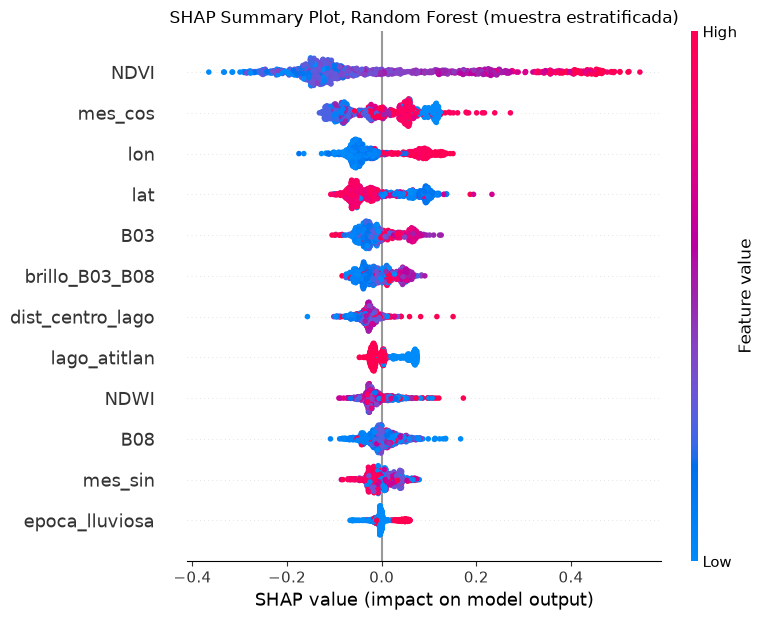

In [8]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_est, X_est, show=False, max_display=12)
plt.title('SHAP Summary Plot, Random Forest (muestra estratificada)', fontsize=12)
plt.tight_layout()
plt.show()

**Lectura del summary plot.** El gráfico confirma el orden de importancia y agrega la dirección:

- **NDVI** produce la nube más extendida, de -0.35 a +0.55. Los puntos rojos (NDVI alto) están todos a la derecha y los azules a la izquierda, sin mezcla. Es una relación monótona y limpia: a más NDVI, más probabilidad de alta presencia.
- **`mes_cos`** aparece en grupos discretos, porque solo hay 11 fechas por lago. Los valores altos caen tanto a la derecha como a la izquierda, así que su efecto no es una tendencia estacional suave sino el reconocimiento de fechas concretas.
- **`lon` y `lat`** muestran dos bloques separados que corresponden a los dos lagos. No hay puntos intermedios porque los lagos no comparten rango de coordenadas.
- **`B03` y `brillo_B03_B08`** empujan hacia la clase 1 cuando son altos, con una amplitud mucho menor (hasta unos 0.1).
- **`NDWI`** tiene puntos rojos y azules a ambos lados del cero, señal de que su efecto depende de con qué otras variables se combine.

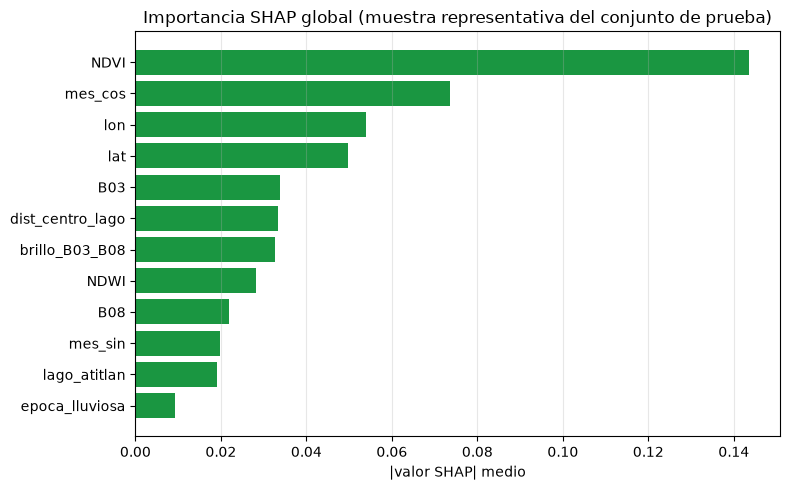

Importancia SHAP media (|SHAP|):
NDVI                0.14363
mes_cos             0.07367
lon                 0.05392
lat                 0.04977
B03                 0.03373
dist_centro_lago    0.03329
brillo_B03_B08      0.03259
NDWI                0.02821
B08                 0.02197
mes_sin             0.01977
lago_atitlan        0.01915
epoca_lluviosa      0.00937


In [9]:
# Importancia SHAP global sobre la muestra representativa
shap_global = pd.Series(np.abs(shap_rep).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
orden_s = shap_global.sort_values(ascending=True)
ax.barh(orden_s.index, orden_s.values, color='#1a9641')
ax.set_xlabel('|valor SHAP| medio')
ax.set_title('Importancia SHAP global (muestra representativa del conjunto de prueba)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Importancia SHAP media (|SHAP|):')
print(shap_global.round(5).to_string())

In [10]:
# Comparación de los tres rankings
ranking = pd.DataFrame({
    'Gini': importancias_gini.rank(ascending=False).astype(int),
    'Permutación': importancias_perm.rank(ascending=False).astype(int),
    'SHAP': shap_global.rank(ascending=False).astype(int),
}).sort_values('SHAP')

print('Posición de cada variable en los tres rankings (1 = más importante):')
print(ranking.to_string())

Posición de cada variable en los tres rankings (1 = más importante):
                  Gini  Permutación  SHAP
NDVI                 1            1     1
mes_cos              2            2     2
lon                  3            4     3
lat                  4            3     4
B03                  6            5     5
dist_centro_lago    11            8     6
brillo_B03_B08       5            7     7
NDWI                 9            9     8
B08                  7           10     9
mes_sin             10            6    10
lago_atitlan         8           11    11
epoca_lluviosa      12           12    12


**Los tres rankings coinciden en la parte alta.** NDVI, `mes_cos`, `lon` y `lat` ocupan las cuatro primeras posiciones en las tres medidas, y `epoca_lluviosa` la última en las tres. Que tres criterios calculados de forma distinta (la estructura interna del bosque, la caída de ROC-AUC al permutar y la atribución local de SHAP) den el mismo orden refuerza la conclusión: el modelo decide sobre todo con el NDVI y con la posición y la fecha del píxel.

## 4. Dirección del efecto de cada variable (8.3)

Para saber si valores altos o bajos de cada variable aumentan la probabilidad de alta presencia de cianobacteria, se calcula la correlación entre el valor de la variable y su valor SHAP en la muestra estratificada. Una correlación positiva significa que a mayor valor de la variable, mayor empuje hacia la clase 1.

In [11]:
direcciones = []
for i, var in enumerate(X_test.columns):
    valores = X_est[var].values
    corr = np.nan if np.std(valores) == 0 else np.corrcoef(valores, shap_est[:, i])[0, 1]
    direcciones.append({
        'Variable': var,
        '|SHAP| medio': np.abs(shap_est[:, i]).mean(),
        'Correlación valor-SHAP': corr,
        'Dirección': 'valores altos -> más cianobacteria' if corr > 0.1
                     else ('valores altos -> menos cianobacteria' if corr < -0.1
                           else 'no monótona o débil')
    })

df_direcciones = pd.DataFrame(direcciones).set_index('Variable').sort_values('|SHAP| medio', ascending=False)
print('Dirección del efecto de cada variable (muestra estratificada):')
print(df_direcciones.round(4).to_string())

Dirección del efecto de cada variable (muestra estratificada):
                  |SHAP| medio  Correlación valor-SHAP                             Dirección
Variable                                                                                    
NDVI                    0.1691                  0.8803    valores altos -> más cianobacteria
mes_cos                 0.0680                  0.2653    valores altos -> más cianobacteria
lon                     0.0593                  0.8851    valores altos -> más cianobacteria
lat                     0.0558                 -0.8058  valores altos -> menos cianobacteria
B03                     0.0347                  0.6421    valores altos -> más cianobacteria
brillo_B03_B08          0.0326                  0.4962    valores altos -> más cianobacteria
dist_centro_lago        0.0310                  0.4686    valores altos -> más cianobacteria
lago_atitlan            0.0284                 -0.9106  valores altos -> menos cianobacteria
NDWI   

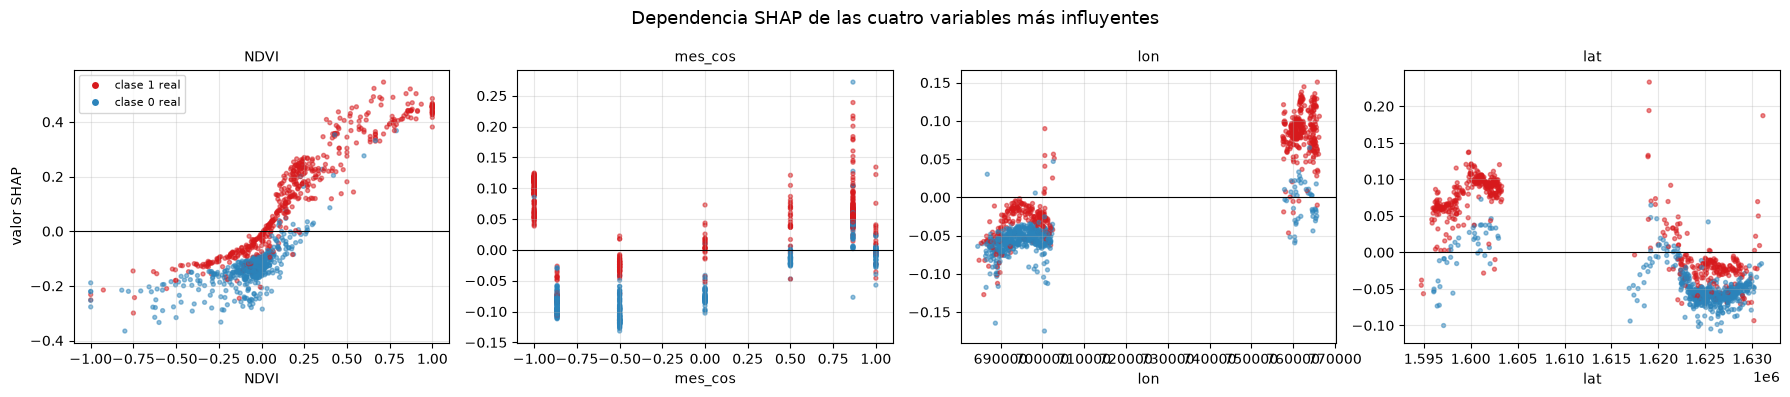

In [12]:
# Gráficos de dependencia para las cuatro variables más influyentes
top4 = df_direcciones.index[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, var in zip(axes, top4):
    j = list(X_test.columns).index(var)
    colores = np.where(y_est.values == 1, '#d7191c', '#2b83ba')
    ax.scatter(X_est[var].values, shap_est[:, j], c=colores, s=8, alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel(var)
    ax.set_ylabel('valor SHAP' if ax is axes[0] else '')
    ax.set_title(f'{var}', fontsize=10)
    ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d7191c', label='clase 1 real', markersize=6),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2b83ba', label='clase 0 real', markersize=6)
], fontsize=8, loc='upper left')

plt.suptitle('Dependencia SHAP de las cuatro variables más influyentes', fontsize=13)
plt.tight_layout()
plt.show()

### Qué dice cada variable (8.3)

**NDVI, la variable dominante.** La curva de dependencia tiene forma de S: por debajo de NDVI = 0 el aporte SHAP es negativo y bastante plano (alrededor de -0.2), cruza el cero cerca de NDVI igual a 0.05 y sube hasta saturarse en torno a +0.45 para NDVI mayor que 0.5. Los píxeles realmente positivos se concentran en la rama ascendente. Ambientalmente tiene sentido: una floración densa en superficie se comporta espectralmente como vegetación flotante, absorbe en el rojo y refleja en el infrarrojo cercano, así que el agua con floración pierde el NDVI negativo típico del agua limpia.

**`mes_cos` no representa una estacionalidad suave.** El gráfico muestra columnas verticales, una por fecha. Los valores negativos, que corresponden a mayo y junio, aportan casi siempre en positivo, mientras que los cercanos a +1, de diciembre a febrero, aportan tanto muy positivo como muy negativo según el píxel. Con solo 11 fechas por lago esta variable funciona en la práctica como identificador de imagen: el modelo aprende qué fechas tuvieron floración en lugar de aprender un ciclo estacional. Encaja con la fecha del 2026-06-19 en Amatitlán, que tuvo 69.15 % de píxeles positivos.

**`lon` y `lat` identifican el lago, no un gradiente.** Los dos paneles muestran dos nubes sin nada en medio. Los píxeles con lon mayor a 750,000 (Amatitlán) reciben aporte positivo y los de lon menor a 710,000 (Atitlán) aporte negativo. La correlación de 0.8851 en `lon` y de -0.8058 en `lat` no describe una tendencia geográfica real, sino que codifica de qué lago se trata. Lo confirma `lago_atitlan`, con correlación -0.9106: ser Atitlán empuja hacia la clase 0. Dentro de Atitlán sí se aprecia algo más fino, una franja alrededor de lat 1,620,000 con aportes positivos, es decir, zonas del lago donde el modelo aprendió que se concentran las floraciones.

**Las bandas aportan poco, pero en la dirección esperada.** B03 (verde, correlación 0.6421), el brillo (0.4962) y B08 (0.1129) empujan hacia la clase 1 cuando son altos, consistente con agua más turbia y con material en suspensión. El NDWI es el caso raro: correlación -0.0027, sin dirección clara. Se explica porque el NDWI ya se usó como máscara de agua en el notebook 01, así que todos los píxeles del dataset están por encima del umbral y queda poca variación aprovechable.

**Estacionalidad.** `epoca_lluviosa` es la variable menos importante, pero su correlación es positiva (0.5263): la época lluviosa empuja hacia la clase 1, coherente con la hipótesis de arrastre de nutrientes al inicio de las lluvias planteada en la Parte I.

## 5. Diferencias entre lagos en la explicación

El notebook 07 mostró que la relación entre bandas y clase cambia de un lago a otro. Aquí se comprueba si el modelo, que sí tiene acceso a la variable `lago_atitlan`, se apoya en variables distintas en cada lago.

In [13]:
filas_lago = []
for lago in ['atitlan', 'amatitlan']:
    mascara = (lago_est.values == lago)
    if mascara.sum() == 0:
        continue
    filas_lago.append(pd.Series(
        np.abs(shap_est[mascara]).mean(axis=0), index=X_test.columns,
        name=f'{lago.capitalize()} (n={mascara.sum()})'
    ))

df_lago_shap = pd.concat(filas_lago, axis=1)
df_lago_shap['Diferencia'] = df_lago_shap.iloc[:, 1] - df_lago_shap.iloc[:, 0]
df_lago_shap = df_lago_shap.sort_values(df_lago_shap.columns[1], ascending=False)

print('|SHAP| medio por lago (muestra estratificada):')
print(df_lago_shap.round(5).to_string())

|SHAP| medio por lago (muestra estratificada):
                  Atitlan (n=663)  Amatitlan (n=337)  Diferencia
NDVI                      0.18934            0.12931    -0.06003
lon                       0.05000            0.07772     0.02772
lat                       0.04689            0.07326     0.02636
mes_cos                   0.06780            0.06831     0.00051
lago_atitlan              0.01416            0.05630     0.04214
B03                       0.02955            0.04491     0.01536
brillo_B03_B08            0.02973            0.03824     0.00851
epoca_lluviosa            0.00454            0.03194     0.02741
mes_sin                   0.01785            0.03028     0.01243
dist_centro_lago          0.03240            0.02839    -0.00401
NDWI                      0.02638            0.02195    -0.00444
B08                       0.02747            0.01814    -0.00933


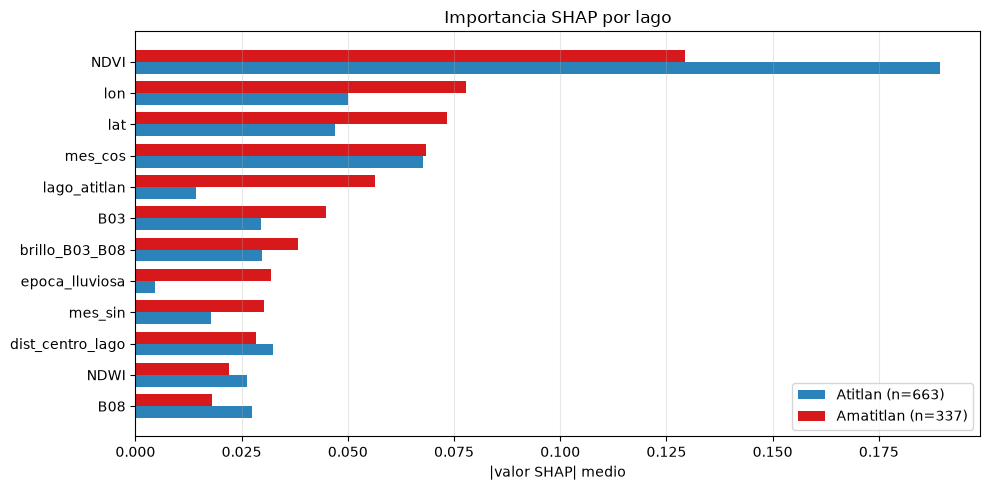

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
orden_l = df_lago_shap.iloc[:, :2].sort_values(df_lago_shap.columns[1], ascending=True)
posiciones = np.arange(len(orden_l))
ancho = 0.38
ax.barh(posiciones - ancho/2, orden_l.iloc[:, 0].values, ancho,
        label=orden_l.columns[0], color='#2b83ba')
ax.barh(posiciones + ancho/2, orden_l.iloc[:, 1].values, ancho,
        label=orden_l.columns[1], color='#d7191c')
ax.set_yticks(posiciones)
ax.set_yticklabels(orden_l.index)
ax.set_xlabel('|valor SHAP| medio')
ax.set_title('Importancia SHAP por lago')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Diferencias entre lagos.** El modelo no se apoya en las mismas variables en los dos lagos:

- En **Atitlán** el NDVI pesa más (|SHAP| medio de 0.18934 frente a 0.12931 en Amatitlán). Como allí las floraciones son escasas y localizadas, el índice espectral es prácticamente lo único que separa un píxel positivo del resto.
- En **Amatitlán** la decisión se reparte más: `lon` (0.07772), `lat` (0.07326), `lago_atitlan` (0.05630) y `epoca_lluviosa` (0.03194) pesan bastante más que en Atitlán. En un lago donde el 11.19 % de los píxeles son positivos y hay fechas con floración casi total, saber en qué zona y en qué momento se tomó el píxel ya aporta mucha información por sí solo.

Este contraste ayuda a entender el resultado del notebook 07: la parte de la decisión que depende de la posición y de la fecha no se puede transferir a otro lago, y en Amatitlán esa parte es mayor.

## 6. Lectura ambiental de los patrones encontrados (8.4)

**El modelo detecta biomasa fotosintética en superficie, que es justo lo que se busca.** La señal dominante es el NDVI alto. Una floración de cianobacterias forma una capa densa cerca de la superficie que absorbe en el rojo y refleja en el infrarrojo cercano, igual que la vegetación terrestre, mientras que el agua limpia absorbe casi todo el infrarrojo cercano y da NDVI negativo. Que el punto de cruce esté cerca de NDVI igual a 0.05, es decir donde el píxel deja de comportarse como agua limpia, indica que el modelo aprendió un criterio físicamente razonable y no un corte arbitrario. B03 y el brillo refuerzan esa lectura: las acumulaciones superficiales dispersan más luz y hacen el agua más brillante y turbia.

**Un matiz importante sobre el NDVI.** El NDVI se calcula como (B08 - B04) / (B08 + B04) y comparte la banda B04 con la fórmula del NDCI, que es la que define la variable respuesta. El notebook 03 lo mantuvo como predictor porque combina B04 con B08 en lugar de con B05, pero su dominio tan marcado en las tres medidas de importancia, con el triple de peso que la segunda variable, sugiere que parte de su capacidad predictiva viene de esa banda compartida y no solo de información espectral independiente. Conviene reportarlo como limitación: es posible que el desempeño esté algo inflado por esta vía. Una comprobación directa sería reentrenar el modelo sin NDVI y medir cuánto desempeño se pierde.

**El modelo también memoriza dónde y cuándo.** Después del NDVI, las variables con más peso son `mes_cos`, `lon` y `lat`, y las tres funcionan como identificadores más que como gradientes ambientales. No es un error del modelo, sino la consecuencia de tener solo 11 fechas por lago y de que la partición aleatoria del notebook 04 coloca píxeles de la misma imagen en entrenamiento y en prueba. Es exactamente el mecanismo que la validación espacial del notebook 06 y la transferencia entre lagos del notebook 07 buscaban exponer, y explica por qué esas dos evaluaciones dan resultados más bajos que la partición aleatoria.

**Consecuencia para el uso operativo.** La parte del modelo aprovechable en zonas nuevas es la que depende de las variables espectrales, sobre todo del NDVI y en menor medida de B03 y del brillo. La parte que depende de coordenadas y fecha solo sirve dentro del mismo lago y del mismo conjunto de imágenes. Para un sistema de monitoreo que deba funcionar en fechas futuras, lo razonable es entrenar sin coordenadas absolutas y con muchas más fechas, de modo que la estacionalidad se aprenda como ciclo y no como lista de imágenes.

## 7. Guardado de resultados

In [15]:
pd.DataFrame(shap_est, columns=X_test.columns).assign(
    y_real=y_est.values, lago=lago_est.values
).to_parquet('./data/shap_muestra_estratificada.parquet', index=False)

pd.DataFrame({
    'Gini': importancias_gini,
    'Permutación': importancias_perm,
    'SHAP': shap_global
}).to_csv('./data/importancia_variables.csv')

df_direcciones.to_csv('./data/direccion_efecto_shap.csv')

print('Guardado:')
print('  ./data/shap_muestra_estratificada.parquet')
print('  ./data/importancia_variables.csv')
print('  ./data/direccion_efecto_shap.csv')

Guardado:
  ./data/shap_muestra_estratificada.parquet
  ./data/importancia_variables.csv
  ./data/direccion_efecto_shap.csv
